# Trajectory Algorithm Project

This notebook aims to introduce trajectory modeling, issues related to radar and flight data, and various algorithms designed to improve the efficiency and robustness of autonomous flight and interception of objects. 

## Modeling a Trajectory and the Noise in its Tracking

In [2]:
import numpy as np

# Random seed
rng = np.random.default_rng(42)

For this preliminary work, we consider a case in which the trajectories under study are linear and have a constant velocity.

$$
\dot{x} = v_x ~~~~ \text{and} ~~~~ \dot{v}_x = 0
$$

The state vector is $[x, y, v_x, v_y]$ is in 2D Cartesian coordinates, but real radar measurements are in polar coordinates.

In [3]:
# matrix of the constant velocity model and linear trajectory
def F_cv(dt):
    return np.array([
        [1, 0, dt, 0], # x
        [0, 1, 0, dt], # y
        [0, 0, 1, 0],  # v_x
        [0, 0, 0, 1],  # v_y
    ])

Addition a Discrete White Noise Acceleration (DWNA). 
We assume that a white random acceleration `q` (continuous white noise) disturbs the target between two time step `dt`, and we analytically integrate its effect on position and velocity. Hence the terms $\mathrm{d}t^3/3$ (variance of position, since the double integral of the noise accumulates over $\mathrm{d}t^3$) and $\mathrm{d}t^2/2$ (cross-covariance between position and velocity).

$$
\text{We got} ~~~~ \dot{x} = v_x  ~~~~ \text{and} ~~~~ \dot{v}_x = w(t)
$$
where $w(t)$ is a white noise with an intensity $q$ (spectral power density).

Over the interval between 2 time steps $[0, \mathrm{d}t]$, the process error added to the true state (relative to the ideal “constant velocity” model) is:

$$
\delta v_x ​= \int_0^{\mathrm{d}t} ​w(s) \mathrm{d}s 
\implies 
\delta x = \int_0^{\mathrm{d}t} \delta v_x​(s) \mathrm{d}s 
= \int_0^{\mathrm{d}t} \int_0^s ​w(\tau) \mathrm{d}\tau \mathrm{d}s
$$

In other words: the same white noise signal $w(t)$ is integrated once to obtain the velocity error, and twice to obtain the position error !

We will use:
- `q13`: The variance of the accumulated position error resulting from the double integration of the unknown random acceleration over the interval $\mathrm{d}t$.
- `q12`: The cross-covariance. It exists because the position error and the velocity error for this time step are calculated from the same random acceleration, and are therefore statistically related: an unexpected positive acceleration simultaneously increases both the final velocity and the final position.
- `dt`: Variance of the velocity error = simple integral of white noise.A linear growth with respect to dt.

In [4]:
# process noise covariance matrix for the constant velocity model
def Q_cv(dt, q):
    """
    Compute the process noise covariance matrix for a constant velocity model.
    dt: time step (s)
    q: process noise intensity
    """
    
    # discrete white noise acceleration model
    q13 = (dt**3) / 3
    q12 = (dt**2) / 2

    Q = q * np.array([
        [q13, 0, q12, 0], # variance on x from the accumulated position error (q13) and the cross terms position-velocity (q12)
        [0, q13, 0, q12], # variance on y from the accumulated position error (q13) and the cross terms position-velocity (q12)
        [q12, 0, dt, 0],  # variance on v_x from the cross terms position-velocity (q12) and the acceleration noise (dt)
        [0, q12, 0, dt]   # variance on v_y from the cross terms position-velocity (q12) and the acceleration noise (dt)
        ])
    
    return Q

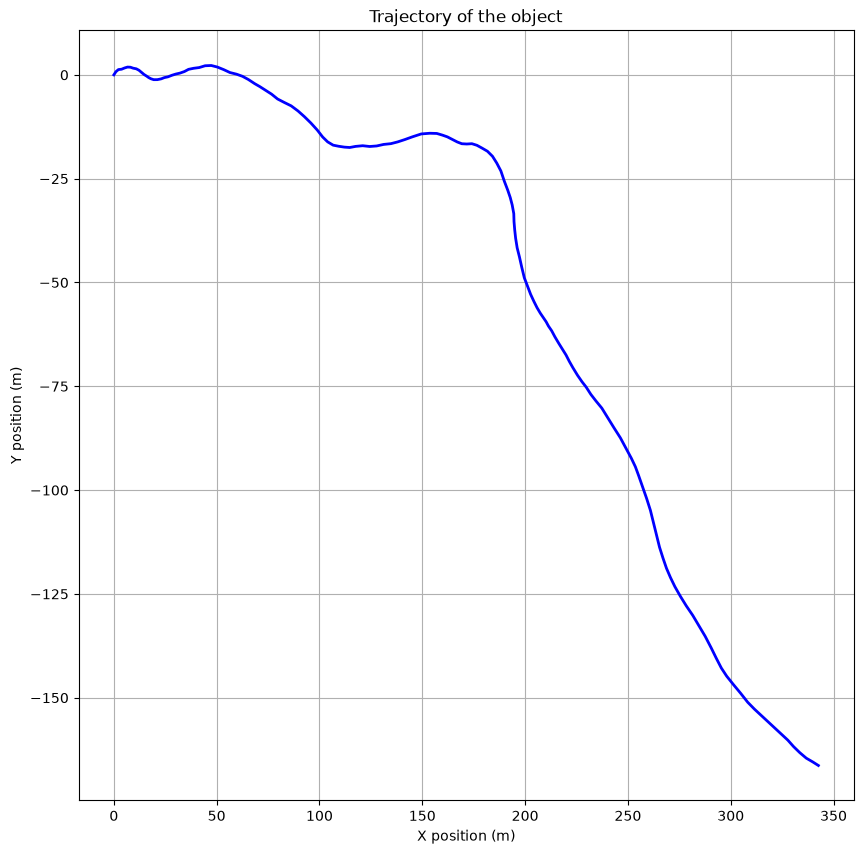

In [5]:
# plot of the trajectory
import matplotlib.pyplot as plt

dt = 1
# final time step
N = 150

# process noise intensity
q = 0.1

# list of positions (x, y)
trajectory = np.array([[0.0, 0.0]]) 
# initial velocity
v = np.array([1.0, 1.0]) 

# matrix of the constant velocity model and linear trajectory
matrix_F = F_cv(dt)

matrix_Q = Q_cv(dt, q=q)

for i in range(1, N):
    
    vector = np.array([trajectory[i-1][0], 
                       trajectory[i-1][1], 
                        v[0], 
                        v[1]]
                        )
    
    # noise part
    noise = rng.multivariate_normal(mean=np.zeros(4), cov=matrix_Q)
    
    # update the position
    coordinate = matrix_F @ vector + noise

    # update the velocity
    v = coordinate[2:4]

    # store the position
    trajectory = np.vstack((trajectory, coordinate[0:2].reshape(1, -1)))

# plot the trajectory
plt.figure(figsize=(10, 10))
plt.title("Trajectory of the object")
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")

plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2)
plt.grid(True)
plt.show()

This allows continuous process uncertainty to be propagated into a discrete system. The parameter $q$ (noise intensity) is the only control that tells the filter that “the target may deviate from the linear model.”
It is this parameter that allows the filter to “follow” the turns without having explicitly modeled them.

In [6]:
def simulate_true_trajectory(dt, N, turn_schedule):
    """
    dt: time step (s)
    N: number of time steps
    turn_schedule: list of (start_step, end_step, omega) turn rate segments (rad/s).
    """
    # Add a verification to ensure that the turn_schedule is valid
    for (s0, s1, om) in turn_schedule:
        if s0 < 0 or s1 > N or s0 >= s1:
            raise ValueError(f"Invalid turn schedule: ({s0}, {s1}, {om})")

    # Initialize the state vector: [x, y, vx, vy]
    state = np.array([0.0, 0.0, 200.0, 0.0])  # (m, m, m/s, m/s)

    # states will hold the trajectory of the object over time
    # we fill it with the initial state and then update it in the loop
    states = [state.copy()]

    # Loop over time steps to simulate the trajectory
    for k in range(1, N):

        t = k * dt  # current time (s)

        # Omega = 0 => straight line motion
        # Omega != 0 => turning motion
        omega = 0.0
        # for every scheduled turn segment
        for (s0, s1, om) in turn_schedule:
            # if we are within a scheduled turn segment
            if s0 <= t < s1:
                # update the turn rate
                omega = om
                break
        
        # Update the state based on the current turn rate
        x, y, vx, vy = state
        # if the turn rate is very small, we can approximate the motion as straight line
        if abs(omega) < 1e-8:
            x += vx * dt
            y += vy * dt
        # otherwise, we need to account for the turning motion
        else:
            # scalar speed and heading
            speed = np.hypot(vx, vy)
            heading = np.arctan2(vy, vx) + omega * dt

            # update the velocity components based on the new heading
            vx = speed * np.cos(heading)
            vy = speed * np.sin(heading)

            x += vx * dt
            y += vy * dt
        
        # Add the updated state to the list of states
        state = np.array([x, y, vx, vy])
        states.append(state.copy())

    return np.array(states)

The heading is updated before the position is advanced, and the position uses the speed after the turn rather than the average speed over the interval. This is a semi-implicit Euler-type scheme (similar to the “symplectic Euler” method) applied to circular motion; it is not the exact solution for an arc of a circle.

For a turn at a constant rate $\omega$, the exact (closed-form) solution for the displacement over $dt$ is known analytically (as used in the classical [Bar-SHalom's CT model](https://www.researchgate.net/profile/Yaakov-Bar-Shalom-2/publication/3002842_Interacting_multiple_model_methods_in_target_tracking_A_survey/links/5b367aeda6fdcc8506df9f47/Interacting-multiple-model-methods-in-target-tracking-A-survey.pdf}) ) 
and involves $\frac{\sin⁡(\omega \mathrm{d}t)}{\omega}$ and $\frac{1 - \cos⁡( \omega \mathrm{d}t)}{\omega}$ rather than a simple $v_x*\mathrm{d}t$. 
The scheme used here therefore introduces an integration error of order $ O (\mathrm{d}t)$ (or even $ O(\mathrm{d}t^2)$ depending on the exact formulation) in position at each turn step, negligible here since $\mathrm{d}t = 1s$ and $\omega$ remains small ($\thicksim 3 ~\text{or}~ 4°/s$, i.e., a rotation of a few degrees per step), but this would no longer be negligible with a larger $\mathrm{d}t$ or a more rapid rate of turn (a missile, for example).

Indeed, the turn procedure assumes a constant speed and a heading that turns at a constant rate:

$$
\theta(t) = \theta_0 + \omega t 
~~~,~~~
v_x(t) = V \cos\theta(t)
~~~,~~~
v_y(t) = V \sin⁡\theta(t)
$$

The exact position is obtained by performing an analytical integration:

$$
x(t) 
= 
x_0 + V \int_0^t \cos⁡(\theta_0 + \omega s) \mathrm{d}s
=
x_0 + \frac{V}{\omega}[\sin⁡(\theta_0 + \omega t) − \sin⁡\theta_0]
$$

By rewriting $V \cos\theta_0 = v_{x0}$ and $V \sin \theta_0 = v_{y0}$ (the cartesian speeds at the beginning of the time step) and $ \sin⁡(\theta_0 + \omega \mathrm{d}t)$ with the addtion formula, we get:

$$
\Delta x = \frac{\sin( \omega \mathrm{d}t)}{\omega} ​v_{x0} ​− \frac{1 - \cos(\omega \mathrm{d}t)}{\omega} v_{y0} 
\\
{}
\\
\Delta y = \frac{1 - \cos( \omega \mathrm{d}t)}{\omega} ​v_{x0} + \frac{\sin(\omega \mathrm{d}t)}{\omega} v_{y0}
$$

## Addition of a radar measurment function

In [7]:
def radar_measurements(states, sigma_r, sigma_theta, radar_pos):
    """
    states: array of shape (N, 4) containing the true states [x, y, vx, vy]
    sigma_r: standard deviation of range measurement noise (m)
    sigma_theta: standard deviation of bearing measurement noise (rad)
    radar_pos: position of the radar (x, y) in meters
    """
    rx, ry = radar_pos
    meas = []
    # for each state
    for s in states:
        # s[0] = x, s[1] = y
        # dx = x-rx and dy = y-ry represents the relative position of the target with respect to the radar
        dx, dy = s[0] - rx, s[1] - ry

        # compute the range
        r = np.hypot(dx, dy)
        # addition of Gaussian noise to the range
        r += rng.normal(0, sigma_r)

        # compute the bearing
        theta = np.arctan2(dy, dx)
        # addition of Gaussian noise to the bearing
        theta += rng.normal(0, sigma_theta)
        
        meas.append([r, theta])
    return np.array(meas)

In [8]:
# time step
dt = 1.0
# number of time steps
N = 150

# Define the turn schedule as a list of tuples (start_time, end_time, turn_rate)
# Here 2 turn segments are defined
turn_schedule = [( 40,   70,    np.radians(3)), # 3°/s turn from t=40s to t=70s
                 (100,  130,   -np.radians(4)), # -4°/s turn from t=100s to t=130s
                 ]

# Simulate the true trajectory and generate radar measurements
states = simulate_true_trajectory(dt, N, turn_schedule)

radar_pos = (5000.0, 5000.0)
meas = radar_measurements(states, sigma_r=50.0, sigma_theta=np.radians(0.5), radar_pos=radar_pos)

print(states.shape, meas.shape, "\n")
print("True states:\n", states[:3], "\n")
print("Radar measurements:\n", meas[:3])

(150, 4) (150, 2) 

True states:
 [[  0.   0. 200.   0.]
 [200.   0. 200.   0.]
 [400.   0. 200.   0.]] 

Radar measurements:
 [[ 7.04503839e+03 -2.34910321e+00]
 [ 6.94317237e+03 -2.35127863e+00]
 [ 6.81988562e+03 -2.31959189e+00]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule):
    """
    Plots the true trajectory and the radar measurements.
    
    states: array of shape (N, 4) containing the true states [x, y, vx, vy]
    meas: array of shape (N, 2) containing the radar measurements [r, theta]
    radar_pos: position of the radar (x, y) in meters
    turn_schedule: list of (start_step, end_step, omega) turn rate segments (rad/s).
    """
    
    # The mesurements are polar (r, theta) -> we convert them to cartesian
    # only for visualization purposes, to display them on the same frame as the true trajectory.
    # ATTENTION : this is only a geometric conversion for plotting, not what the filter actually does (which works directly in (r, theta)).
    meas_x = radar_pos[0] + meas[:, 0] * np.cos(meas[:, 1])
    meas_y = radar_pos[1] + meas[:, 0] * np.sin(meas[:, 1])

    fig, ax = plt.subplots(figsize=(9, 7))

    # True trajectory
    ax.plot(states[:, 0], states[:, 1], color="tab:blue", lw=2, label="True trajectory")
    ax.scatter(states[0, 0], states[0, 1], color="tab:blue", marker="o", s=60, zorder=5, label="Target start")

    # Turn segments : we highlight them on the true trajectory
    for (s0, s1, om) in turn_schedule:
        ax.plot(states[s0:s1, 0], states[s0:s1, 1], color="orange", lw=3,
                label="Turn" if (s0, s1, om) == turn_schedule[0] else None)

    # radar measurements (noisy, reconverted to cartesian)
    ax.scatter(meas_x, meas_y, color="tab:red", s=12, alpha=0.7, label="Radar measurements (noisy)")

    # Position of the radar
    ax.scatter(*radar_pos, color="black", marker="^", s=140, label="Radar")

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("True trajectory and noisy radar measurements")
    ax.legend(loc="best")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

    plt.tight_layout()

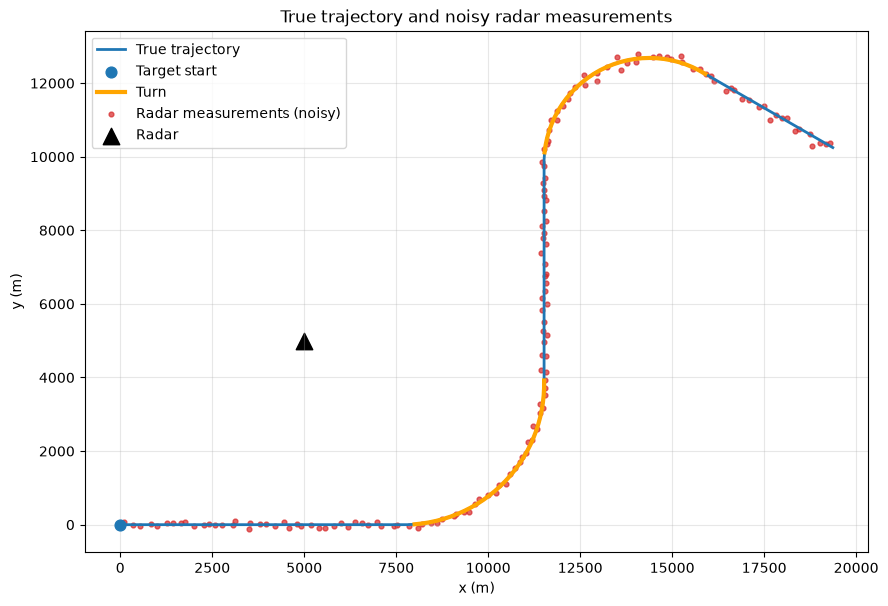

In [10]:
plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule)

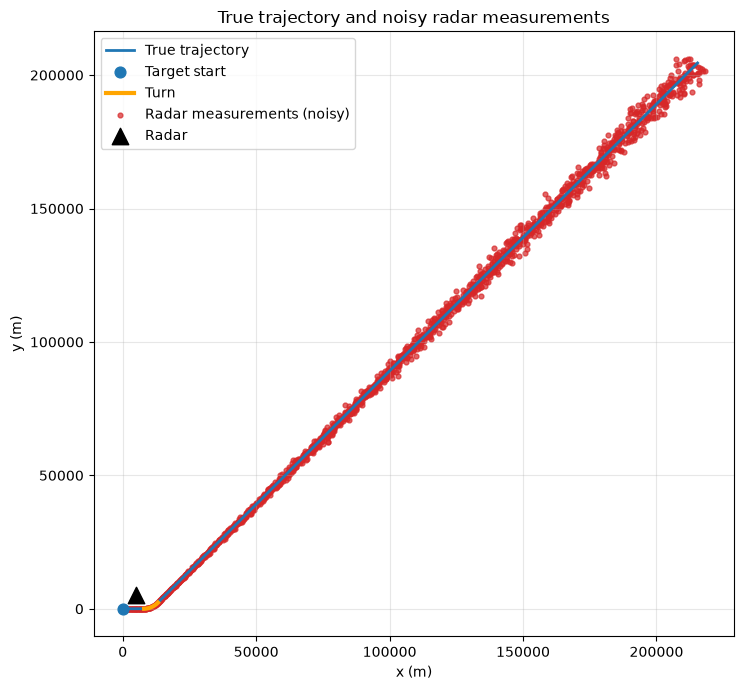

In [11]:
# time step
dt = 1.0
# number of time steps
N = 1500

turn_schedule = [( 40,   70,    np.radians(1.5))]

# Simulate the true trajectory and generate radar measurements
states = simulate_true_trajectory(dt, N, turn_schedule)

radar_pos = (5000.0, 5000.0)
meas = radar_measurements(states, sigma_r=50.0, sigma_theta=np.radians(0.5), radar_pos=radar_pos)

plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule)

# Filters

A radar does not “see” a position ($x$, $y$, $v_x$, $v_y$), it measures a distance and an angle, both of which are subject to noise, at regular intervals. It leads to different problems:

- **Measurement noise directly affects our understanding of the trajectory**. Without a filter, the "estimated trajectory" is simply the true trajectory plus radar noise. The filter takes advantage of the fact that the target follows a consistent physical dynamic from one moment to the next to smooth out this noise. To do so, we add a prediction step (`F_cv`, `Q_cv`): It incorporates prior information ("the target is likely where its dynamics predict it to be"), which compensates for the uncertainty in the raw measurement.

- **Some quantities are never measured directly**. The radar never measures speed, but the filter estimates it anyway, because it observes how the measured position changes over time and deduces the speed consistent with that change, using the position-velocity coupling in the dynamic model.

To manage the complex dynamics of a trajectory and the noise, we use the extended Kalman filter (EKF) by linearisation. 

In [12]:
# function of measurement model for radar (the same that in the previous section)
def h_radar(x, radar_pos=radar_pos):
    # Relative position of the target with respect to the radar
    dx, dy = x[0] - radar_pos[0], x[1] - radar_pos[1]
    # Range
    r = np.hypot(dx, dy)
    # bearing
    theta = np.arctan2(dy, dx)

    return np.array([r, theta])

Jacobian of the measurement model for radar where the first-order local nonlinearization that replaces the constant H in the linear Kalman filter. 

Direct derivation: 
$ 
\partial r / \partial x = \mathrm{d} x / r ~~~\text{and}~~~ \partial \theta / \partial x = \mathrm{d} y / r^2
$
(derived of $\arctan⁡2$)

/!\ `H` has only 2 nonzero columns (out of 4), `h` depends only on position, not on velocity. In other words: a radar measurement alone provides no direct information about velocity. Velocity is estimated only indirectly, through the coupling introduced by the dynamic model (`F_cv`), which links position and velocity over time. 

In [13]:
def H_jacobian(x, radar_pos=radar_pos):
    # Relative position of the target with respect to the radar
    dx, dy = x[0] - radar_pos[0], x[1] - radar_pos[1]
    # Range
    r = np.hypot(dx, dy)
    # Range squared
    r2 = dx**2 + dy**2
    
    # Jacobian matrix of the radar measurement model
    H = np.zeros((2, 4))
    H[0, 0] = dx / r
    H[0, 1] = dy / r
    H[1, 0] = -dy / r2
    H[1, 1] = dx / r2

    return H

This function maps any angle difference to $(-\pi, \pi]$

In [14]:
def angle_residual(a, b):
    d = a - b
    return (d + np.pi) % (2 * np.pi) - np.pi

#### Extended Kalman filter (EKF) object

We seek to estimate, at each time step $k$, the probability distribution of the state $x_k$. This is a problem of recursive Bayesian inference with a Markov dynamics ($x_k = f(x_{k-1})$) and Gaussian noise (fully characterized by its mean $\hat{x}$ and its covariance $P$).

The idea: 
We have a prediction $x_k ​\sim \mathcal{N}(\hat{x}_k^{-}​,P_k​)$ (the output of `predict`), and a new measurement $z_k$. We want the *posterior* distribution $p(\mathbf{x}_k \mid z_k)$, based on the linearised model around $\hat{x}_k^{-}$.

$$
z_k \approx h(\hat{x}_k^{-}​) + H(x_k ​− \hat{x}_k^{-}​) + v_k ~~~\text{and}~~~ v_k \sim \mathcal{N}(0,R)
$$

$H$ is no longer a fixed matrix specified a priori, it is the Jacobian of $h$, reevaluated at each step at the current point `self.x`.

| Mathematical notation | Variable in the code | Moments |
|:-------- |:--------:| --------:|
| $\hat{x}_{k−1}​, P_{k−1}$     | `self.x`, `self.P` before calling `predict()`   | a posteriori, previous step    |
| $\hat{x}_{k}^{-}​, P_{k}^{-}$     | `self.x`, `self.P` just after `predict()` and before `update()`   | a priori    |
| $\hat{x}_{k}​, P_{k}$     | `self.x`, `self.P` after `update()`   | a posteriori, current step   



**Derivation of the Kalman Gain**: $x_k$ and $z_k$ are jointly Gaussian, with:
$$
\mathrm{Cov}(x_k​,z_k​) = P_k^{-} − ​H^\mathrm{T} 
~~~\text{and}~~~ 
\mathrm{Cov}(z_k​) = H P_k^{-} − ​H^\mathrm{T} + R =: S
$$

The standard Gaussian distribution formula directly yields:
$$
x_k ​= x_k^{−} ​+ \underbrace{ P_k^− ​H^\mathrm{T} S^{−1} }_{K} ​\underbrace{ ​(z_k ​− h(x_k^−​)) }_{y}
~~~\text{and}~~~ 
P_k​=P_k^− ​− K S K^\mathrm{T} = (I_d − K H) P_k^-
$$

In [15]:
class EKF:
    def __init__(self, x0, P0, q, R):
        # Initialize the Extended Kalman Filter with:
        # Intial state
        self.x = x0.copy()
        # Initial covariance, it quantify the uncertainty of the initial state
        self.P = P0.copy()
        # Intensity of the process noise (confidence in the dynamic model)
        self.q = q
        # Covariance of the measurement noise (confidence in the sensor)
        self.R = R

    def predict(self, dt):
        F = F_cv(dt)
        # Prediction of the state (mean)
        self.x = F @ self.x
        # Prediction of the covariance (uncertainty),
        # based on the previous covariance (P) and the process noise covariance (Q)
        self.P = F @ self.P @ F.T + Q_cv(dt, self.q)
    
    # Update step of the EKF and uncertainty
    def update(self, z, radar_pos=radar_pos):
        # Jacobian of the measurement model at the predicted state
        H = H_jacobian(self.x, radar_pos)
        # Compute the predicted measurement based on the current state estimate
        z_pred = h_radar(self.x, radar_pos)

        # Compute the innovation (measurement residual)
        # the difference between what the radar actually measured and what the filter expected to measure
        y = np.array([z[0] - z_pred[0], angle_residual(z[1], z_pred[1])])
        # Covariance of the innovation (residual)
        S = H @ self.P @ H.T + self.R
        # Compute the Kalman gain
        K = self.P @ H.T @ np.linalg.inv(S)

        # Update the state estimate and covariance based on the innovation and Kalman gain
        self.x = self.x + K @ y
        self.P = (np.eye(self.P.shape[0]) - K @ H) @ self.P

        return y, S

**Unscented Kalman Filter**: UKF is an alternative to EKF that avoids analytical (Jacobian) linearization by using deterministic sampling. 
Instead of calculating $H = \partial h/ \partial x$, we select a small set of representative points located around the mean $\hat{x}$, and we pass each of these points as is through the nonlinear function h. We then reconstruct the mean and covariance from the transformed points.

# Trajectory of interception using proportional navigation (PN)

Proportional navigation is based on the fact that two objects are on a collision course when their line of sight (LOS) does not change direction as the range closes.
It dictates that the missile should accelerate at a rate proportional to the line of sight's rotation rate, and in the same direction. This gradually nullifies the LOS rotation and keeps the missile on a collision course.

Simply put, the strategy involves looking at the angle from which you see the target. If that angle remains constant as the distance decreases, then you are on a collision course.

In 2D, such as a planar engagement, pure proportional navigation can be represented as:
$$
{a_{n}=N{\dot {\lambda }}V}
$$
where:
- ${a_{n}}$ is a scalat that represents the acceleration perpendicular to the missile's instantaneous velocity vector
- ${N}$ is the proportionality constant generally having an integer value 3-5 (dimensionless). If $N$ is high, the covergence of the collision course, but demand an higher lateral acceleration.
- ${\dot {\lambda}}$ is the line of sight rotation rate
- ${V}$ is the closing velocity.

In [ ]:
import numpy as np

def simulate_pn_intercept(target_pos0, target_vel, pursuer_pos0, pursuer_speed,
                            N_gain=4.0, dt=0.01, t_max=60.0, max_accel=90.0):
    """
    2D proportional navigation. Target flies straight at constant velocity.
    Pursuer speed is fixed magnitude; PN law commands lateral acceleration.
    """
    tp = np.array(target_pos0, dtype=float)
    tv = np.array(target_vel, dtype=float)
    pp = np.array(pursuer_pos0, dtype=float)
    # initial pursuer heading: pointed at target
    los = tp - pp
    heading = np.arctan2(los[1], los[0])
    pv = pursuer_speed * np.array([np.cos(heading), np.sin(heading)])

    hist = {'t': [], 'target': [], 'pursuer': [], 'miss_rate': [], 'accel_cmd': []}
    t = 0.0
    min_range = np.linalg.norm(los)

    while t < t_max:
        rel_pos = tp - pp
        rel_vel = tv - pv
        r = np.linalg.norm(rel_pos)
        hist['t'].append(t)
        hist['target'].append(tp.copy())
        hist['pursuer'].append(pp.copy())
        min_range = min(min_range, r)

        if r < 5.0:  # intercept
            break

        los_rate = (rel_pos[0] * rel_vel[1] - rel_pos[1] * rel_vel[0]) / (r**2)  # d(lambda)/dt
        closing_vel = -np.dot(rel_pos, rel_vel) / r

        a_cmd_mag = N_gain * closing_vel * los_rate  # PN law
        a_cmd_mag = np.clip(a_cmd_mag, -max_accel, max_accel)
        hist['accel_cmd'].append(a_cmd_mag)
        hist['miss_rate'].append(los_rate)

        # lateral acceleration applied perpendicular to pursuer velocity
        pv_dir = pv / np.linalg.norm(pv)
        perp = np.array([-pv_dir[1], pv_dir[0]])
        pv = pv + a_cmd_mag * perp * dt
        pv = pv / np.linalg.norm(pv) * pursuer_speed  # keep speed constant

        pp = pp + pv * dt
        tp = tp + tv * dt
        t += dt

    # 
    for k in ['t', 'target', 'pursuer']:
        hist[k] = np.array(hist[k])
    return hist, min_range

hist, miss = simulate_pn_intercept(
    target_pos0=[20000, 3000], target_vel=[-150, 40],
    pursuer_pos0=[0, 0], pursuer_speed=340, N_gain=4.0,
)
print("Miss distance (m):", miss, " Intercept time (s):", hist['t'][-1])

Miss distance (m): 2.061007288331662  Intercept time (s): 42.490000000000116


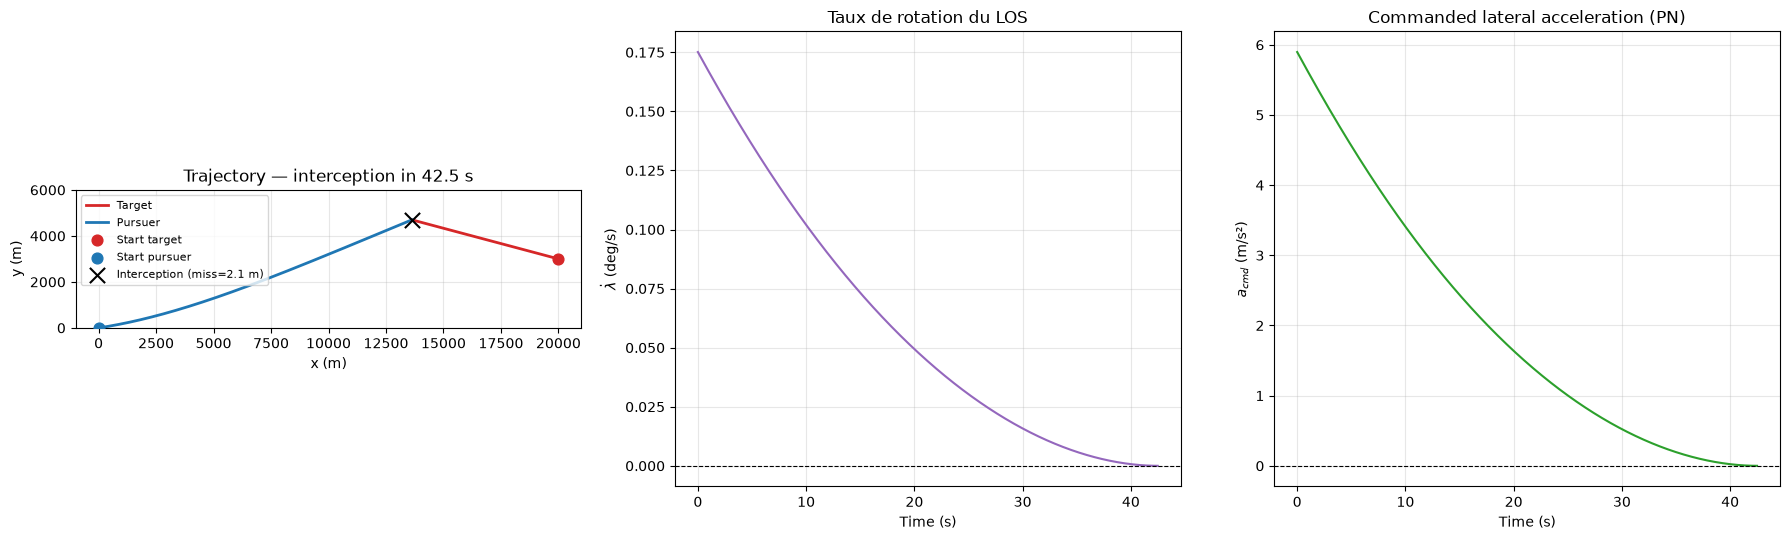

In [22]:
import numpy as np
import matplotlib.pyplot as plt

hist, miss = simulate_pn_intercept(
    target_pos0=[20000, 3000], target_vel=[-150, 40],
    pursuer_pos0=[0, 0], pursuer_speed=340, N_gain=4.0,
)

t = hist['t']
target = hist['target']   # (Nt, 2)
pursuer = hist['pursuer']  # (Nt, 2)
accel_cmd = np.array(hist['accel_cmd'])
los_rate = np.array(hist['miss_rate'])  # d(lambda)/dt

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1) Trajectory
ax = axes[0]
ax.plot(target[:, 0], target[:, 1], color="tab:red", lw=2, label="Target")
ax.plot(pursuer[:, 0], pursuer[:, 1], color="tab:blue", lw=2, label="Pursuer")
ax.scatter(*target[0], color="tab:red", marker="o", s=60, zorder=5, label="Start target")
ax.scatter(*pursuer[0], color="tab:blue", marker="o", s=60, zorder=5, label="Start pursuer")
ax.scatter(*pursuer[-1], color="black", marker="x", s=120, zorder=6,
           label=f"Interception (miss={miss:.1f} m)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Trajectory — interception in {t[-1]:.1f} s")
ax.legend(loc="best", fontsize=8)
ax.set_aspect("equal")
ax.set_ylim(0,6000)
ax.grid(alpha=0.3)

# 2) Rotation rate of the LOS (must converge to 0)
ax = axes[1]
ax.plot(t[:len(los_rate)], np.degrees(los_rate), color="tab:purple")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\dot\lambda$ (deg/s)")
ax.set_title("Taux de rotation du LOS")
ax.grid(alpha=0.3)

# 3) Accélération latérale commandée
ax = axes[2]
ax.plot(t[:len(accel_cmd)], accel_cmd, color="tab:green")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$a_{cmd}$ (m/s²)")
ax.set_title("Commanded lateral acceleration (PN)")
ax.grid(alpha=0.3)

plt.tight_layout()